# Gradient descent

Gradient descent is a powerful optimization algorithm used in machine learning and deep learning to minimize a function, often a cost function, by iteratively moving towards the minimum point

Gradient descent is a method for unconstrained mathematical optimization. It is a first-order iterative algorithm for minimizing a differentiable multivariate function.

The idea is to take repeated steps in the opposite direction of the gradient (or approximate gradient) of the function at the current point, because this is the direction of steepest descent.

## Gradient Descent: Simple Explanation
Gradient Descent is a method to minimize the loss (error) by adjusting model parameters (like weights) gradually.

**Gradient Descent minimizes the loss function by computing the partial derivatives (gradients) of the loss with respect to each parameter (like weights and biases), and then updating those parameters in the opposite direction of the gradient.**

## How it works step-by-step:

**Let’s say we have a loss function L(w, b), where:**

- w = weights
- b = bias

**1. Compute partial derivatives (gradients):**

 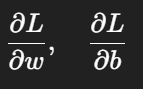

**2. Update the parameters using learning rate (α):**

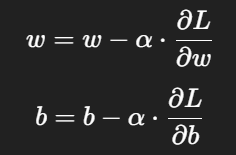

This process is repeated (iterated) until the loss reaches a minimum (ideally global or at least local minimum).

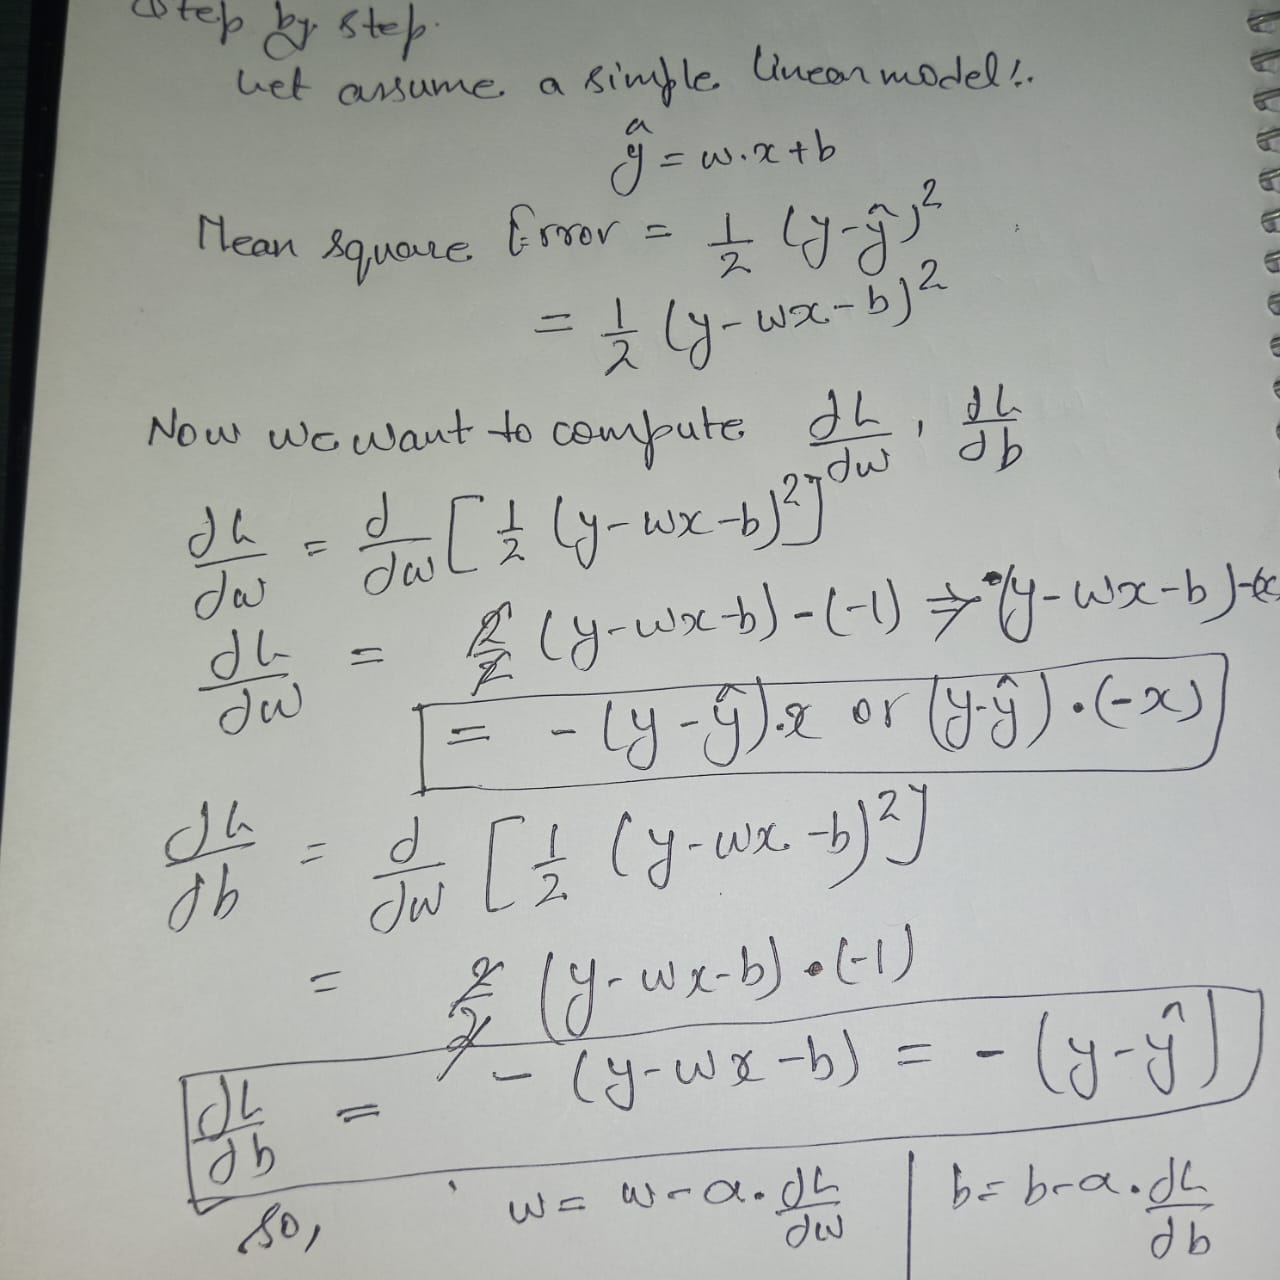

## Types of Gradient Descent

| Type                                  | Description                                                                    |
| ------------------------------------- | ------------------------------------------------------------------------------ |
| **Batch Gradient Descent**            | Uses the **entire training set** to compute gradient at each step              |
| **Stochastic Gradient Descent (SGD)** | Uses **one sample at a time** for faster updates                               |
| **Mini-batch Gradient Descent**       | Uses **small batches** (e.g., 32 or 64 samples) – widely used in deep learning |


**Where is GD used?**
- Linear Regression
- Logistic Regression
- Neural Networks
- Deep Learning models
- Any model with differentiable loss function

## Various Optimization Algorithms 

**1. Gradient-Based Optimization**
- a. Gradient Descent (GD)
- b. Stochastic Gradient Descent (SGD)
- c. Mini-Batch Gradient Descent

**2. Advanced Variants of SGD (Optimizers)**
These optimizers improve on vanilla SGD by adapting the learning rate or using momentum.
- a. Momentum
- b. Nesterov Accelerated Gradient (NAG)
- c. Adagrad
- d. RMSProp
- e. Adam (Adaptive Moment Estimation)

**3. Second-Order Optimization**
- a. Newton's Method
- b. L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)

**4. Evolutionary / Nature-Inspired Optimization**
- a. Genetic Algorithms
- b. Particle Swarm Optimization (PSO)
- c. Simulated Annealing

**5. Bayesian Optimization**

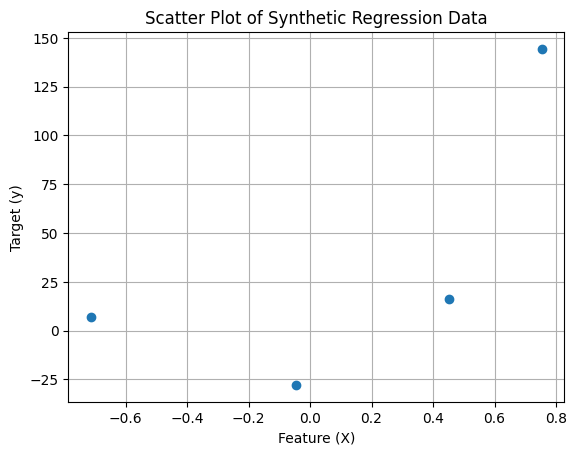

In [4]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

# Generate a synthetic regression dataset and visualize it

"""
This script generates a small synthetic regression dataset using `make_regression` 
from scikit-learn, and visualizes the relationship between the feature(s) and target.

- `n_samples=4`      : Creates a dataset with 4 data points.
- `n_features=1`     : Each sample has 1 feature.
- `n_informative=1`  : The number of informative features is 1 (all features are useful for prediction).
- `n_targets=1`      : Generates a single continuous target variable.
- `noise=80`         : Adds Gaussian noise with standard deviation 80 to simulate real-world data.
- `random_state=13`  : Ensures reproducibility of the dataset.

The dataset is then plotted using matplotlib:
- `plt.scatter(X, y)` creates a scatter plot of the feature vs the target.
"""

# Code execution
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, 
                       n_targets=1, noise=80, random_state=13)

plt.scatter(X, y)
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Scatter Plot of Synthetic Regression Data")
plt.grid(True)
plt.show()

[78.35063668]
26.15963284313262


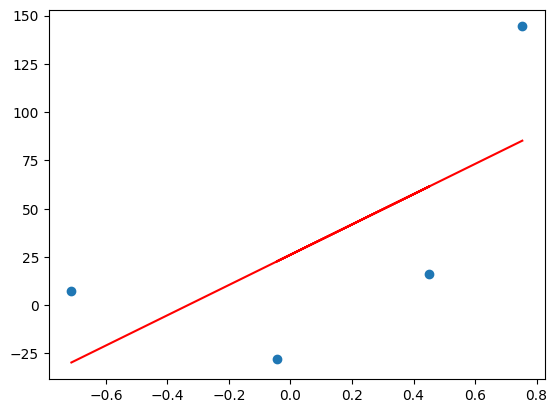

In [5]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)     
print(reg.coef_)
print(reg.intercept_)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0

     

In [7]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [8]:
y_pred = ((78.35 * X) + 0).reshape(4)  ## y=mx+b  

In [10]:
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

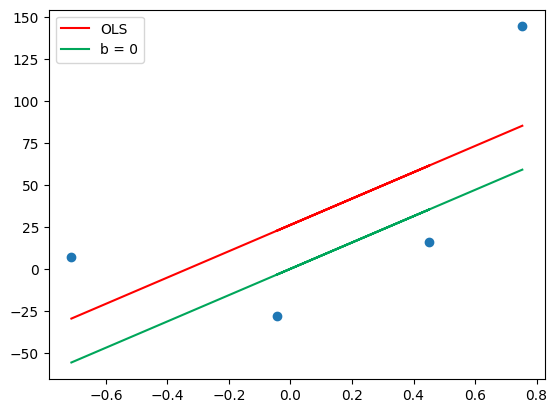

In [11]:

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()
     

**the equation is from the OLS Loss partial derivatives with respect to b**
- 2 * np.sum(y - m*X.ravel() - b) 
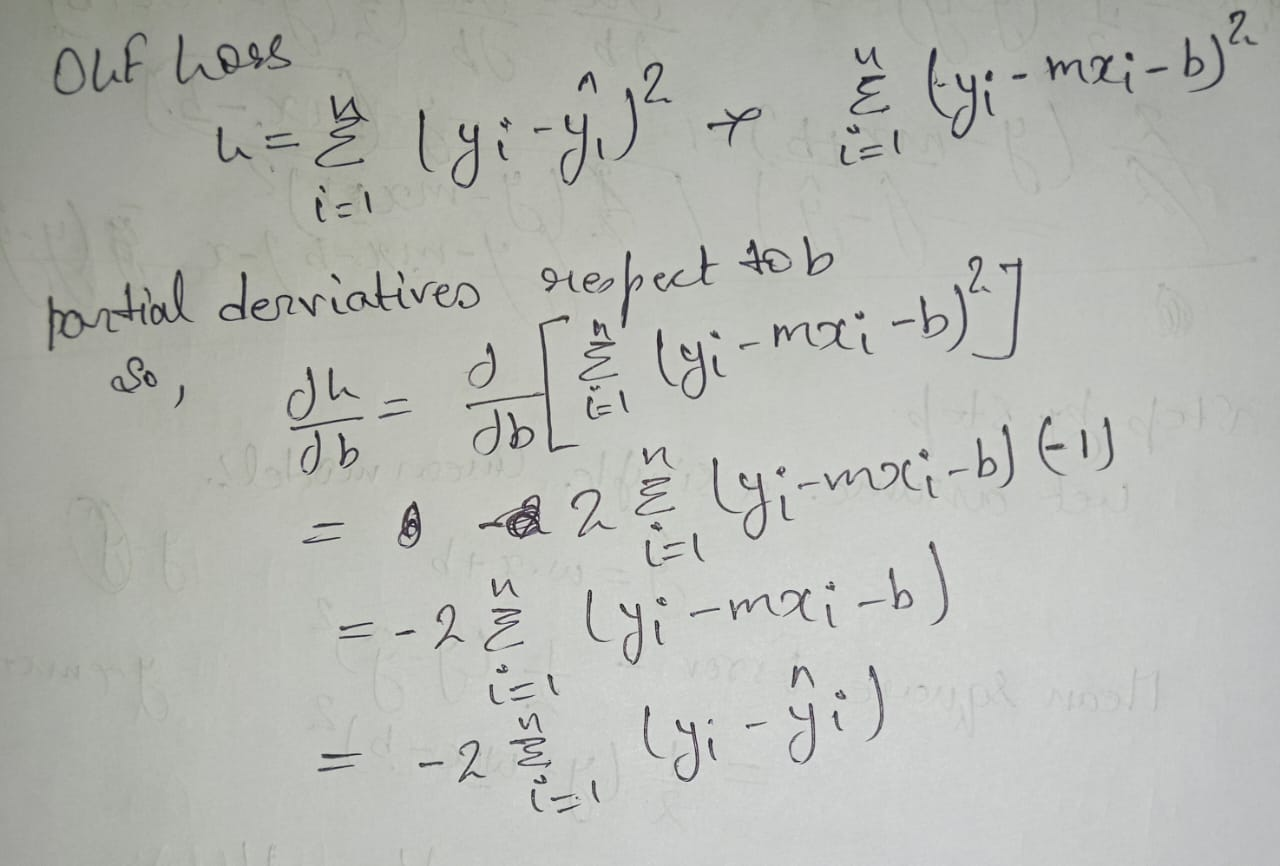

##  Iteration 1

In [19]:
# Iteration 1
m=78.35
b=0

loss_slope= - 2 * np.sum(y - m*X.ravel() - b)  ## the equation is from the OLS partial derivatives with respect to b  
loss_slope

-209.27763408209216

In [21]:
# Lets take learning rate = 0.1
lr=0.1

step_size=loss_slope*lr  ## (loss_slope*lr) is the learning rate into slope
step_size

-20.927763408209216

In [23]:
# Calculating the new intercept
b = b - step_size   ## bnew=bold-step_size
b

20.927763408209216

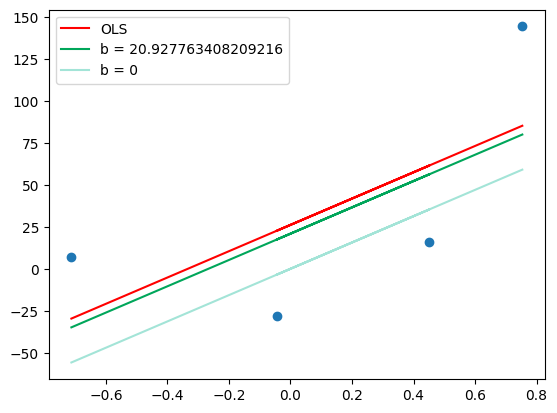

In [25]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     


## Iteration 2

In [28]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-41.85552681641843

In [30]:
step_size = loss_slope*lr
step_size

-4.185552681641844

In [32]:
b = b - step_size
b
   

25.11331608985106

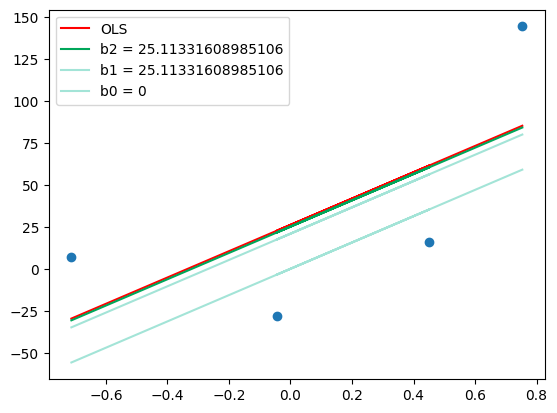

In [34]:

y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b2 = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b1 = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b0 = 0')
plt.legend()
plt.show()
     

## Iteration 3

In [37]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-8.371105363283675

In [39]:

step_size = loss_slope*lr
step_size

-0.8371105363283675

In [41]:

b = b - step_size
b

25.95042662617943

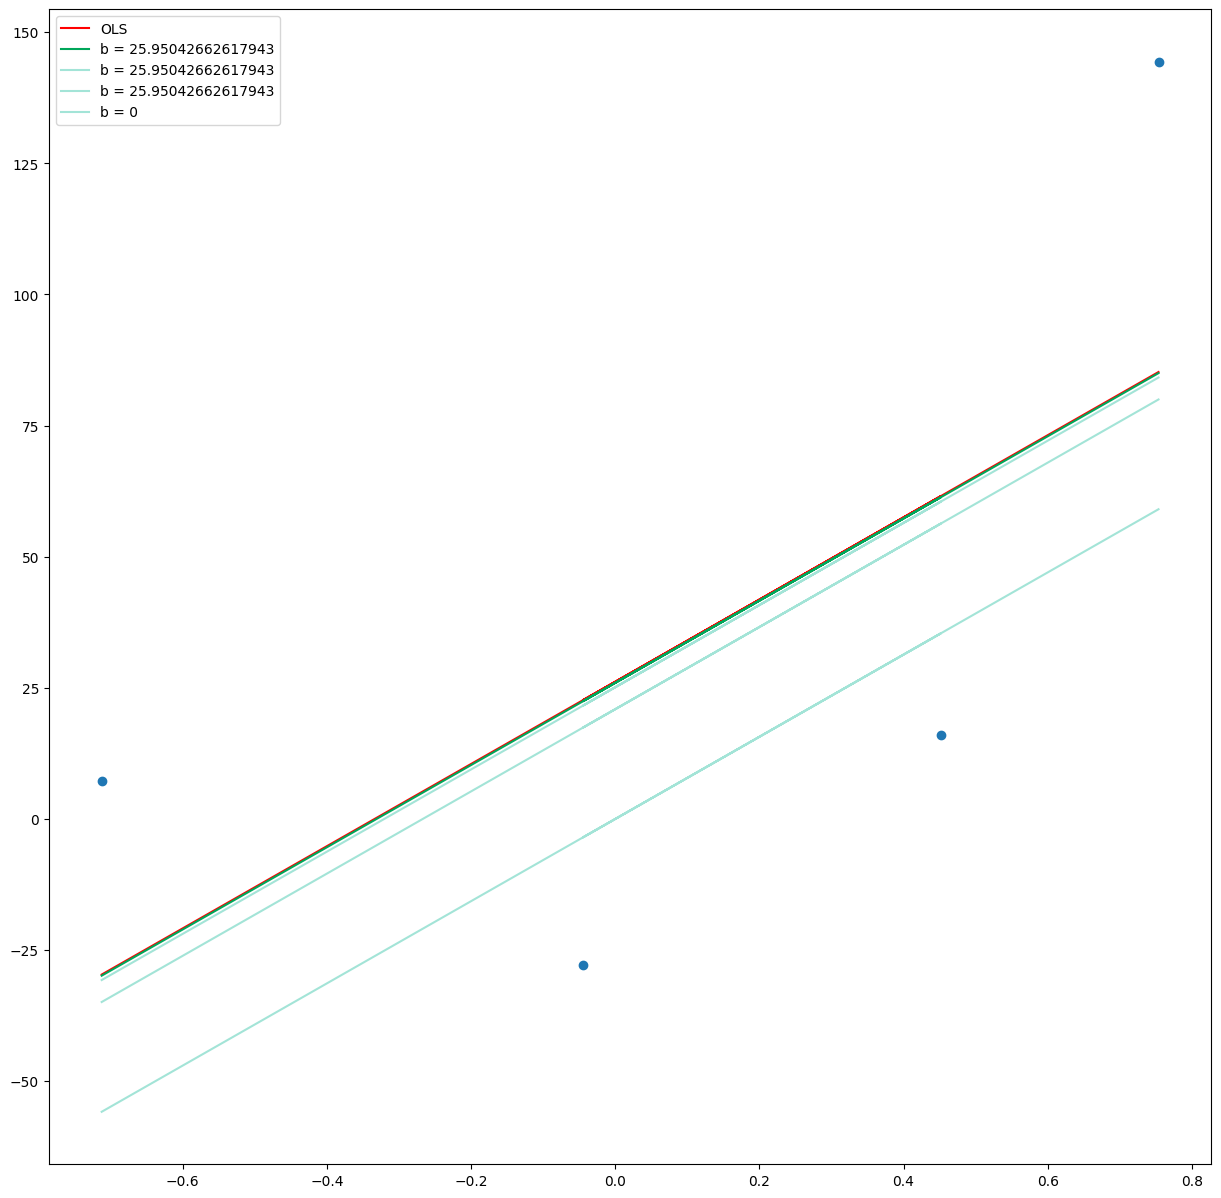

In [43]:

y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

------------- 

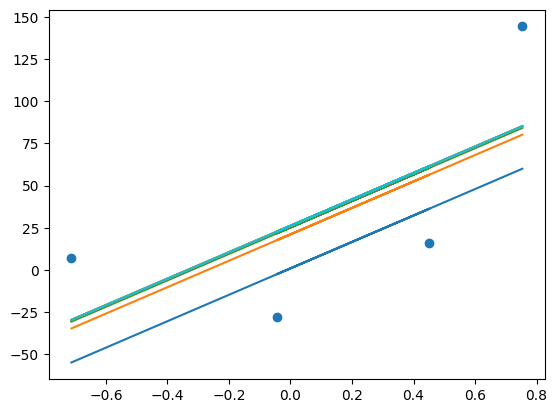

In [46]:
b=-100 # any value 
m=78.35  # fixed
lr=0.1   #fixed

epochs=10  ## Iteration

for i in range(epochs):
    loss_slope= -2 * np.sum(y - m*X.ravel() - b)  ## partial  derivative or slope
    b = b -(lr * loss_slope) ## GD optim

    y_pred= m * X + b  ## prediction

    plt.plot(X,y_pred)

plt.scatter(X,y)
    

----------

----------

In [50]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [52]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

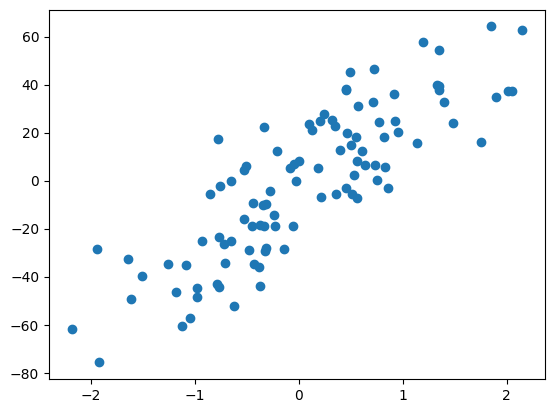

In [54]:
plt.scatter(X,y)

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [60]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

# Class

In [63]:
class GDRegressor:

    def __init__(self,lr,epochs):
        self.m=28.12597332  ## taken from the lr.coef_ model
        self.b= -120 ## any value to start
        self.lr=lr
        self.epochs=epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope= -2 * np.sum(y - self.m*X.ravel() - self.b)
            

            self.b = self.b - (self.lr * loss_slope)
            
            print(loss_slope,self.b)

        print(self.b)

    

In [65]:
g1=GDRegressor(0.001,100)

In [67]:
g1. fit(X,y)

-23537.57138280849 -96.4624286171915
-18830.057106246793 -77.63237151094471
-15064.045684997433 -62.56832582594728
-12051.236547997945 -50.51708927794933
-9640.989238398357 -40.87610003955098
-7712.791390718687 -33.16330864883229
-6170.23311257495 -26.993075536257344
-4936.18649005996 -22.056889046197384
-3948.9491920479677 -18.107939854149414
-3159.159353638375 -14.94878050051104
-2527.327482910699 -12.42145301760034
-2021.8619863285596 -10.39959103127178
-1617.489589062848 -8.782101442208933
-1293.9916712502784 -7.488109770958655
-1035.1933370002225 -6.452916433958432
-828.1546696001778 -5.624761764358254
-662.5237356801423 -4.962238028678112
-530.0189885441138 -4.432219040133997
-424.015190835291 -4.008203849298706
-339.2121526682327 -3.6689916966304734
-271.3697221345862 -3.397621974495887
-217.09577770766893 -3.180526196788218
-173.67662216613505 -3.006849574622083
-138.9412977329082 -2.867908276889175
-111.15303818632637 -2.7567552387028487
-88.92243054906109 -2.6678328081537876


------

------

## For b and m

In [95]:
class GDRegressor:

    def __init__(self,lr,epochs):
        self.m=-100  ## taken from the lr.coef_ model
        self.b= -120 ## any value to start
        self.lr=lr
        self.epochs=epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b= -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m= -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            # print(loss_slope,self.b)

        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b
    

In [97]:
gd=GDRegressor(0.001,50)

In [99]:
gd.fit(X_train,y_train)

28.10082423618001 -2.2794678794533136
